In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
"""
Nandi Maize Suitability Model — Tiled Low-RAM Version
======================================================
RAM efficient.

File structure: /content/drive/MyDrive/02_NandiSeedRecommender2/
"""

import os, gc
import numpy as np
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import rowcol
import geopandas as gpd
import pandas as pd
from scipy import stats
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap, BoundaryNorm
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SECTION 0: PATHS AND SETTINGS
# ============================================================

BASE         = '/content/drive/MyDrive/02_NandiSeedRecommender2'
DIR_SOIL     = os.path.join(BASE, 'Soil_Data')
DIR_SOIL_UNC = os.path.join(BASE, 'Soil_Data_Uncertainty')
DIR_CLIMATE  = os.path.join(BASE, 'Climate_Data')
DIR_EXTREME  = os.path.join(BASE, 'Climate_Extreme_Data')
DIR_TERRAIN  = os.path.join(BASE, 'Terrain_Data')
DIR_COUNTIES = os.path.join(BASE, 'NandiCounties')
DIR_OUT      = os.path.join(BASE, 'Outputs')
os.makedirs(DIR_OUT, exist_ok=True)

ONI_CSV    = os.path.join(DIR_EXTREME, 'RONI.csv')
COUNTY_SHP = os.path.join(DIR_COUNTIES, 'counties.shp')

N_MC        = 100
TILE_SIZE   = 256    # pixels per tile side — increase if RAM allows, decrease if not
RANDOM_SEED = 42
rng         = np.random.default_rng(RANDOM_SEED)

# ============================================================
# SECTION 1: SPATIAL REFERENCE
# ============================================================

VALID_MASK      = None
NANDI_TRANSFORM = None
RASTER_SHAPE    = None
REF_PROFILE     = None

def build_spatial_mask():
    global VALID_MASK, NANDI_TRANSFORM, RASTER_SHAPE, REF_PROFILE
    template = os.path.join(DIR_SOIL, 'iSDA_pH_0-20cm.tif')
    counties = gpd.read_file(COUNTY_SHP)
    nandi    = counties[counties['COUNTY_NAM'] == 'NANDI']
    with rasterio.open(template) as src:
        VALID_MASK      = geometry_mask(nandi.geometry, src.shape,
                                        src.transform, all_touched=True, invert=True)
        NANDI_TRANSFORM = src.transform
        RASTER_SHAPE    = src.shape
        REF_PROFILE     = src.profile.copy()
    print(f"Grid: {RASTER_SHAPE[0]} x {RASTER_SHAPE[1]} pixels")

build_spatial_mask()

# ============================================================
# SECTION 2: MEMBERSHIP FUNCTIONS
# ============================================================

MF = {
    'mean_season_rain': ([0,300,400,500,600,750,900,1200,1600],
                         [0.25,0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.60]),
    'prec_month_lr':    ([0,60,75,100,125,175,220,295,400,475],     # used for all 4 months LR
                         [0.25,0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.6,0.25]),
    'prec_month_sr':    ([0,60,75,100,125,175,220,295,400,475],
                         [0.25,0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.6,0.25]),
    'mean_temp':        ([0,14,16,18,22,24,26,32,35,40],
                         [0.25,0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.6,0.25]),
    'germination_temp': ([0,10,13,18,21,24,29],
                         [0.0,0.4,0.85,1.0,0.85,0.4,0.0]),
    'min_temp':         ([0,7,9,12,16,17,18,24,28,30],
                         [0.25,0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.6,0.25]),
    'max_temp':         ([24,26,32,35,40],
                         [1.0,0.95,0.85,0.60,0.25]),
    'rh_development':   ([0,30,36,42,50,65,80],
                         [0.25,0.6,0.85,0.95,1.0,1.0,0.95]),
    'rh_maturation':    ([0,20,24,30,40,50,75,90],
                         [0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.6]),
    'crop_failure_freq':([0.0,0.025,0.05,0.075,0.10,0.125,
                          0.15,0.175,0.20,0.225,0.25],
                         [1.0,0.98,0.95,0.88,0.73,0.50,
                          0.27,0.12,0.05,0.02,0.0]),
    'slope':            ([0,4,8,16,30,50],
                         [1.0,0.95,0.85,0.60,0.40,0.25]),
    'stone_content':    ([0,3,15,35,55],
                         [1.0,0.95,0.85,0.60,0.25]),
    'bedrock_depth':    ([0,20,50,75,100],
                         [0.25,0.6,0.85,0.95,1.0]),
    'ph':               ([0,5.2,5.5,5.8,6.2,6.6,7.0,7.8,8.2,8.5],
                         [0.4,0.6,0.85,0.95,1.0,1.0,0.95,0.85,0.6,0.25]),
    'ecec':             ([0,5,10],
                         [0.85, 0.95, 1.0]),

    'cec_apparent': ([0, 10, 16, 24], [0.4, 0.85, 0.95, 1.0]),
    'organic_carbon':   ([0,0.5,0.7,1.5,2.7],
                         [0.4,0.6,0.85,0.95,1.0]),
    'total_nitrogen':   ([0,0.1,0.15,0.2],
                         [0.6,0.85,0.95,1.0]),
    'calcium':          ([0,1,2],
                         [0.6, 0.85, 1.0]),
    'magnesium':        ([0,0.2,0.5,1.0],
                         [0.25,0.4,0.6,1.0]),
    'potassium':        ([0,0.1,0.24],
                         [0.85,0.95,1.0]),
    'phosphorus':       ([0,6,30],      # advisory
                         [0.4,0.6,1.0]),
    'zinc': ([0, 5.0], [0.95, 1.0]),
    'iron': ([0, 10.0], [0.95, 1.0]),
}

TEXTURE_SCORES = {1:0.83,2:0.25,3:0.85,4:1.0,5:1.0,6:0.95,
                  7:0.95,8:1.0,9:0.85,10:1.0,11:0.77,12:0.6}

ADVISORY_VARS   = {'stone_content', 'bedrock_depth', 'phosphorus'}
LOG_NORMAL_VARS = {
    'organic_carbon',
    'phosphorus',
    'potassium',
    'total_nitrogen',
    'calcium',
    'magnesium'
}

BOUNDS = {
    'ph':             (3.5,  10.0),
    'organic_carbon': (0.0,  20.0),
    'ecec':           (0.0, 100.0),
    'calcium':        (0.0, 100.0),
    'magnesium':      (0.0,  50.0),
    'potassium':      (0.0,  10.0),
    'total_nitrogen': (0.0,   5.0),
    'phosphorus':     (0.0, 200.0),
    'stone_content':  (0.0, 100.0),
    'bedrock_depth':  (0.0, 250.0),
    'zinc': (0.0, 50.0),
    'iron': (0.0, 200.0),
}

# Soil variables that go through the Liebig minimum (clay excluded — no MF)
SOIL_MC_VARS = ['ph','organic_carbon','total_nitrogen','ecec',
                'calcium','magnesium','potassium',
                'phosphorus','stone_content','bedrock_depth', 'clay_content', 'zinc', 'iron']

# ============================================================
# SECTION 3: FULL-RASTER LOADING (soil, terrain, climate means)
# These are small enough to keep in RAM throughout.
# ============================================================

def load_full(filepath, mask_zeros=False):
    """Load and mask a full raster. Coarse rasters skip shape-check masking."""
    if not os.path.exists(filepath):
        print(f"  MISSING: {os.path.basename(filepath)}")
        return None
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(np.float32)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
    if VALID_MASK is not None and data.shape == VALID_MASK.shape:
        data[~VALID_MASK] = np.nan
    if mask_zeros:
        data[data <= 0] = np.nan
    else:
        data[data < 0]  = np.nan
    return data


def isda_log_decode(arr):
    if arr is None: return None
    return np.expm1(arr / 10.0)


def load_soil():
    print("Loading soil data with Sys et al. (1991) depth-weighting...")
    soil = {}

    # --- HELPERS ---

    def get_top(mu_file, sd_file, scale=1.0, is_log=True, log_exponent=10.0):
        """Loads 0-20cm layer. Decodes mean only. Scales both."""
        m = load_full(os.path.join(DIR_SOIL, mu_file), mask_zeros=True)
        s = load_full(os.path.join(DIR_SOIL_UNC, sd_file))

        if is_log and m is not None:
            # Only m is decoded. log_exponent is 100.0 for Nitrogen, 10.0 otherwise.
            m = np.expm1(m / log_exponent)

        if m is not None: m *= scale
        if s is not None: s *= scale # Standard deviation is strictly linear
        return (m, s)

    def get_weighted(mu_f1, mu_f2, sd_f1, sd_f2, is_log=True):
        """Loads two depths. Decodes means only. Propagates variance for SD."""
        m1 = load_full(os.path.join(DIR_SOIL, mu_f1))
        m2 = load_full(os.path.join(DIR_SOIL, mu_f2))
        s1 = load_full(os.path.join(DIR_SOIL_UNC, sd_f1))
        s2 = load_full(os.path.join(DIR_SOIL_UNC, sd_f2))

        if any(v is None for v in [m1, m2, s1, s2]): return (None, None)

        # Means: Decode before weighting
        m1_dec = np.expm1(m1 / 10.0) if is_log else m1
        m2_dec = np.expm1(m2 / 10.0) if is_log else m2
        mu_w = (2.0 * m1_dec + 1.5 * m2_dec) / 3.5

        # SD: Linear variance propagation
        sd_w = np.sqrt(4.0 * (s1**2) + 2.25 * (s2**2)) / 3.5
        return (mu_w, sd_w)

    # --- CATEGORY A: Topsoil Only (0-20cm) ---

    soil['ph'] = get_top('iSDA_pH_0-20cm.tif', 'iSDA_pH_stdev_0-20cm.tif', 0.1, is_log=False)

    # OC: expm1(x/10)/10 for %
    soil['organic_carbon'] = get_top('iSDA_Organic_Carbon_0-20cm.tif', 'iSDA_Organic_Carbon_stdev_0-20cm.tif', 0.1, is_log=True)

    # Nitrogen: expm1(x/100)/10 for % (Corrected exponent)
    soil['total_nitrogen'] = get_top('iSDA_Total_Nitrogen_0-20cm.tif', 'iSDA_Total_Nitrogen_stdev_0-20cm.tif',
                                     0.1, is_log=True, log_exponent=100.0)

    soil['calcium']   = get_top('iSDA_Calcium_0-20cm.tif', 'iSDA_Calcium_stdev_0-20cm.tif', 1/200.39, is_log=True)
    soil['magnesium'] = get_top('iSDA_Magnesium_0-20cm.tif', 'iSDA_Magnesium_stdev_0-20cm.tif', 1/121.53, is_log=True)
    soil['potassium'] = get_top('iSDA_Potassium_0-20cm.tif', 'iSDA_Potassium_stdev_0-20cm.tif', 1/390.98, is_log=True)
    soil['phosphorus'] = get_top('iSDA_Phosphorus_0-20cm.tif', 'iSDA_Phosphorus_stdev_0-20cm.tif', 1.0, is_log=True)
    soil['zinc'] = get_top('iSDA_Zinc_0-20cm.tif', 'iSDA_Zinc_stdev_0-20cm.tif', 1.0, is_log=True)
    soil['iron'] = get_top('iSDA_Iron_0-20cm.tif', 'iSDA_Iron_stdev_0-20cm.tif', 1.0, is_log=True)

    # --- CATEGORY B: B-Horizon Only (20-50cm) ---

    soil['ecec'] = get_top('iSDA_cation_exchange_capacity_20-50cm.tif', 'iSDA_ECEC_stdev_20-50cm.tif', 1.0, is_log=True)

    # --- CATEGORY C: Weighted Profile ---

    soil['stone_content'] = get_weighted('iSDA_stone_content_0-20cm.tif', 'iSDA_stone_content_20-50cm.tif',
                                         'iSDA_Stones_stdev_0-20cm.tif', 'iSDA_Stones_stdev_20-50cm.tif')

    soil['clay_content']  = get_weighted('iSDA_Clay_Content_0-20cm.tif', 'iSDA_Clay_Content_20-50cm.tif',
                                         'iSDA_Clay_stdev_0-20cm.tif', 'iSDA_Clay_stdev_20-50cm.tif')

    soil['bedrock_depth'] = get_top('iSDA_Bedrock_Depth_0-200cm.tif', 'iSDA_Bedrock_stdev_0-200cm.tif', 1.0, is_log=False)

    # Texture remains separate for score weighting in tile loop
    tx_top = load_full(os.path.join(DIR_SOIL, 'iSDA_Texture_Class_0-20cm.tif'), mask_zeros=True)
    tx_sub = load_full(os.path.join(DIR_SOIL, 'iSDA_Texture_Class_20-50cm.tif'), mask_zeros=True)

    return soil, (tx_top, tx_sub)

def load_terrain(elevation):
    slope = load_full(os.path.join(DIR_TERRAIN, 'Nandi_Slope_Percent.tif'), mask_zeros=False)
    return slope


def zoom_to_30m(arr, target_shape, order=1):
    if arr is None: return None
    if arr.shape == target_shape: return arr
    z_r = target_shape[0] / arr.shape[0]
    z_c = target_shape[1] / arr.shape[1]
    return zoom(arr.astype(np.float32), (z_r, z_c), order=order)


def load_climate(elevation):
    """Load and upscale all climate mean rasters. Returns dict season -> dict."""
    print("Loading climate data...")
    H, W = elevation.shape
    climate = {}
    for season in ['LongRains', 'ShortRains']:
        s   = season
        sfx = 'lr' if 'Long' in s else 'sr'
        raw = {
            'mean_season_rain': load_full(os.path.join(DIR_CLIMATE, f'Mean_Season_Rain_{s}.tif')),
            'prec_month1':      load_full(os.path.join(DIR_CLIMATE, f'Prec_Month1_{s}.tif')),
            'prec_month2':      load_full(os.path.join(DIR_CLIMATE, f'Prec_Month2_{s}.tif')),
            'prec_month3':      load_full(os.path.join(DIR_CLIMATE, f'Prec_Month3_{s}.tif')),
            'prec_month4':      load_full(os.path.join(DIR_CLIMATE, f'Prec_Month4_{s}.tif')),
            'mean_temp':        load_full(os.path.join(DIR_CLIMATE, f'MeanTemp_{s}.tif')),
            'min_temp':         load_full(os.path.join(DIR_CLIMATE, f'MinTemp_{s}.tif')),
            'max_temp':         load_full(os.path.join(DIR_CLIMATE, f'MaxTemp_{s}.tif')),
            'germin_temp':      load_full(os.path.join(DIR_CLIMATE, f'GerminationTemp_{s}.tif')),
            'rh_dev':           load_full(os.path.join(DIR_CLIMATE, f'RH_Development_{s}.tif')),
            'rh_mat':           load_full(os.path.join(DIR_CLIMATE, f'RH_Maturation_{s}.tif')),
        }
        out = {}
        for k, arr in raw.items():
            if arr is None:
                out[k] = None
                continue
            if k in ['mean_temp','min_temp','max_temp','germin_temp']:
                # Lapse-rate correction
                t_30m = zoom_to_30m(arr, (H, W), order=1)
                t_30m = np.where(np.isnan(t_30m) & VALID_MASK, np.nanmean(t_30m), t_30m)
                # Downsample elevation to coarse grid then fill NaNs before zooming back  # CHANGE
                e_coarse = zoom_to_30m(elevation, (arr.shape[0], arr.shape[1]), order=1)  # CHANGE
                e_coarse_filled = np.where(                                                # ADD
                    np.isfinite(e_coarse), e_coarse, np.nanmean(e_coarse))                # ADD
                e_ref = zoom_to_30m(e_coarse_filled, (H, W), order=1)                    # CHANGE
                out[k] = t_30m + (elevation - e_ref) * (-0.0065)
            else:
                out[k] = zoom_to_30m(arr, (H, W), order=1)
        climate[season] = out
    return climate


# ============================================================
# SECTION 4: ENSO PHASE COUNTS (incremental, no stacking)
# ============================================================

def load_enso_phases():
    df = pd.read_csv(ONI_CSV)
    df.columns = df.columns.str.strip()
    phases = {'LongRains': {}, 'ShortRains': {}}
    for _, row in df.iterrows():
        yr = int(row['Year'])
        phases['LongRains'][yr]  = str(row['LR_Phase']).strip()
        phases['ShortRains'][yr] = str(row['SR_Phase']).strip()
    return phases


def compute_long_run_pi(phases_dict):
    counts = {'EN': 0, 'LN': 0, 'N': 0}
    for ph in phases_dict.values():
        if ph in counts: counts[ph] += 1
    total = sum(counts.values())
    return {p: counts[p] / total for p in counts}


def compute_phase_counts_incremental(season, phases_by_year, target_shape):
    """
    Accumulates counts for 5 distinct risk bands per ENSO phase.
    Bands: 0:Cold, 1:Heat, 2:Drought, 3:Flood, 4:Overall
    """
    print(f"  Computing 5-band phase risk counts for {season}...")
    H, W = target_shape

    # Initialize 3D arrays to hold 5 layers of counts for each phase
    phase_k = {'EN': np.zeros((5, H, W), dtype=np.float32),
               'LN': np.zeros((5, H, W), dtype=np.float32),
               'N':  np.zeros((5, H, W), dtype=np.float32)}
    phase_n = {'EN': 0, 'LN': 0, 'N': 0}

    # Match your season naming convention for the files
    sfx = 'LR' if 'Long' in season else 'SR'

    for yr in range(1981, 2024):
        phase = phases_by_year.get(yr)
        if phase not in phase_k: continue

        # Look for the new 5-band files
        fpath = os.path.join(DIR_EXTREME, f'Fail_5Band_{sfx}_{yr}.tif')
        if not os.path.exists(fpath): continue

        with rasterio.open(fpath) as src:
            # Read all 5 bands (Shape: 5, H_small, W_small)
            data = src.read().astype(np.float32)
            if src.nodata is not None:
                data[data == src.nodata] = np.nan

        # Process each band separately to upscale to 30m
        for b in range(5):
            band_30m = zoom_to_30m(data[b], target_shape, order=0)

            if VALID_MASK is not None:
                band_30m[~VALID_MASK] = np.nan

            valid = np.isfinite(band_30m)
            # Add this year's binary 0/1 to the running phase total
            phase_k[phase][b] = np.where(valid, phase_k[phase][b] + band_30m, phase_k[phase][b])

        phase_n[phase] += 1
        del data

    result = {}
    for p in ['EN', 'LN', 'N']:
        if phase_n[p] == 0:
            result[p] = (None, 0)
        else:
            # Diagnostic print for the 'Overall' band (Band 4)
            mean_rate = np.nanmean(phase_k[p][4] / phase_n[p])
            #print(f"    Phase {p}: {phase_n[p]} years, Avg Overall Failure: {mean_rate:.3f}")
            result[p] = (phase_k[p], phase_n[p])
    return result


# ============================================================
# SECTION 5: TILE ITERATOR
# ============================================================

def tile_iterator(H, W, tile_size=TILE_SIZE):
    """Yield (r0, r1, c0, c1) tile bounds covering the full raster."""
    for r0 in range(0, H, tile_size):
        r1 = min(r0 + tile_size, H)
        for c0 in range(0, W, tile_size):
            c1 = min(c0 + tile_size, W)
            yield r0, r1, c0, c1


def n_tiles(H, W, tile_size=TILE_SIZE):
    import math
    return math.ceil(H / tile_size) * math.ceil(W / tile_size)


# ============================================================
# SECTION 6: PER-TILE MC
# ============================================================

def score_mf(values, mf_key):
    x, y = MF[mf_key]
    return np.interp(values, x, y).astype(np.float32)


def sample_tile(mu_tile, sd_tile, var_name, n_mc):
    """
    Sample n_mc realisations for a tile.
    mu_tile, sd_tile: 2D arrays (th, tw)
    Returns: (n_mc, th, tw) float32
    Replaces scipy truncnorm with vectorised numpy normal + clip.
    The distributions are identical in practice (bounds are wide relative to sigma).
    """
    lo, hi = BOUNDS.get(var_name, (0.0, 1e6))
    th, tw = mu_tile.shape

    sd_safe = np.where(np.isfinite(sd_tile) & (sd_tile > 1e-8), sd_tile, 1e-4)
    sd_safe = np.clip(sd_safe, 1e-4, 1e6)

    # Draw ALL n_mc samples in one vectorised call
    z = rng.standard_normal((n_mc, th, tw)).astype(np.float32)

    if var_name in LOG_NORMAL_VARS:
        eps    = 1e-8
        mu_log = np.log(np.maximum(mu_tile, eps))
        sg_log = np.clip(sd_safe / np.maximum(np.abs(mu_tile), eps), 1e-6, 5.0)
        samples = np.exp(mu_log[np.newaxis] + sg_log[np.newaxis] * z)
    else:
        samples = (mu_tile[np.newaxis] + sd_safe[np.newaxis] * z)

    return np.clip(samples, lo, hi).astype(np.float32)


def sample_failure_tile(phase_counts, long_run_pi, n_mc, th, tw):
    """Sample all 5 ENSO-conditioned failure bands for one tile."""
    phases  = ['EN', 'LN', 'N']
    pi_arr  = np.array([long_run_pi.get(p, 1/3) for p in phases])
    pi_arr /= pi_arr.sum()

    n_bands = 5
    n_pix   = th * tw

    k_flat = {}
    n_ph   = {}
    for p in phases:
        k_arr, n = phase_counts.get(p, (None, 0))
        n_ph[p]  = n
        # k_arr is (5, th, tw) -> reshape to (5, n_pix)
        k_flat[p] = np.nan_to_num(k_arr.reshape(n_bands, -1), nan=0.0).astype(np.float64) \
                    if k_arr is not None else np.zeros((n_bands, n_pix))

    out = np.zeros((n_mc, n_bands, th, tw), dtype=np.float32)
    for i in range(n_mc):
        p = phases[rng.choice(len(phases), p=pi_arr)]
        k = k_flat[p]
        n = n_ph[p]

        if n == 0:
            samples = rng.beta(1.0, 1.0, size=(n_bands, n_pix)).astype(np.float32)
        else:
            alpha = 1.0 + k
            beta  = np.maximum(1.0 + n - k, 1e-6)
            samples = rng.beta(alpha, beta).astype(np.float32)

        out[i] = samples.reshape(n_bands, th, tw)
    return out

def process_tile(r0, r1, c0, c1,
                 soil, slope_full, texture_full, climate_s,
                 phase_counts_full, long_run_pi, n_mc,
                 season_label):
    """
    Run full MC for one tile. Returns (s_mean, s_std, limit_counts) for that tile.
    All arrays are sliced from pre-loaded full-raster data (soil, terrain, climate).
    Phase counts are sliced from the full-raster k arrays.
    """
    th, tw = r1 - r0, c1 - c0
    risk_names = ['prob_cold', 'prob_heat', 'prob_drought', 'prob_flood', 'prob_overall_fail']

    # ---- Slice phase counts for this tile ----
# ---- Slice phase counts for this tile ----
    phase_counts_tile = {}
    for p, (k_arr, n) in phase_counts_full.items():
        if k_arr is not None:
            # Added ":" to ensure we get all 5 risk bands for the tile area
            phase_counts_tile[p] = (k_arr[:, r0:r1, c0:c1], n)
        else:
            phase_counts_tile[p] = (None, n)

    # ---- Calculate Weighted Climate Risks (Diagnostic Only) ----
    stress_labels = ['prob_cold', 'prob_heat', 'prob_drought', 'prob_flood', 'prob_overall_fail']
    tile_risks = {name: np.zeros((th, tw), dtype=np.float32) for name in risk_names}

    for p, (k_stack, n) in phase_counts_tile.items():
        if n > 0 and k_stack is not None:
            weight = long_run_pi.get(p, 0)
            for b_idx in range(5):
                # We calculate the weighted historical probability (0.0 to 1.0)
                tile_risks[risk_names[b_idx]] += (k_stack[b_idx] / n) * weight

    # ---- Deterministic scores ----
    sl_tile  = slope_full[r0:r1, c0:c1]   if slope_full   is not None else np.ones((th,tw),np.float32)
    sc_slope = score_mf(sl_tile, 'slope')

    # Unpack the texture tuple and slice each depth
    tx_top_full, tx_sub_full = texture_full
    tx_top_tile = tx_top_full[r0:r1, c0:c1]
    tx_sub_tile = tx_sub_full[r0:r1, c0:c1]

    def get_tex_score(tile):
        res = np.full(tile.shape, np.nan, dtype=np.float32)
        if tile is not None:
            for cls, score in TEXTURE_SCORES.items():
                res[np.round(tile).astype(int) == cls] = score
        return res

    # Weight the scores: 2.0 for top (0-20), 1.5 for subsoil (20-50)
    sc_tex = (2.0 * get_tex_score(tx_top_tile) + 1.5 * get_tex_score(tx_sub_tile)) / 3.5

    # Climate (all already at 30m)
    def cs(key, mf_key):
        arr = climate_s.get(key)
        if arr is None: return np.ones((th, tw), np.float32)
        return score_mf(arr[r0:r1, c0:c1], mf_key)

    sfx = 'lr' if 'Long' in season_label else 'sr'
    sc_rain  = np.fmin.reduce([  # CHANGE
        cs('mean_season_rain', 'mean_season_rain'),
        cs('prec_month1', f'prec_month_{sfx}'),
        cs('prec_month2', f'prec_month_{sfx}'),
        cs('prec_month3', f'prec_month_{sfx}'),
        cs('prec_month4', f'prec_month_{sfx}'),
    ])
    sc_temp  = np.fmin.reduce([  # CHANGE
        cs('mean_temp',   'mean_temp'),
        cs('min_temp',    'min_temp'),
        cs('max_temp',    'max_temp'),
        cs('germin_temp', 'germination_temp'),
    ])
    sc_rh    = np.fmin(cs('rh_dev', 'rh_development'),  # CHANGE
                       cs('rh_mat', 'rh_maturation'))

    # ---- Stochastic: failure probability ----

    fail_samples = sample_failure_tile(phase_counts_tile, long_run_pi, n_mc, th, tw) # CHANGE
    sc_fail_mc   = score_mf(fail_samples[:, 4, :, :], 'crop_failure_freq') # CHANGE
    risk_names   = ['prob_cold', 'prob_heat', 'prob_drought', 'prob_flood', 'prob_overall_fail'] # CHANGE

    # ---- Stochastic: soil samples ----
    soil_samples = {}
    for var in SOIL_MC_VARS:
        mu_t, sd_t = soil[var]
        if mu_t is None or sd_t is None: continue
        mu_sl = mu_t[r0:r1, c0:c1]
        sd_sl = sd_t[r0:r1, c0:c1]
        soil_samples[var] = sample_tile(mu_sl, sd_sl, var, n_mc)

    # ---- Liebig minimum ----
    # Ensure this matches every key you put into the 'scores' dictionary below

    climate_stages = ['min_temp', 'max_temp', 'germin_temp', 'rh_dev', 'rh_mat',
                      'prec_month1', 'prec_month2', 'prec_month3', 'prec_month4']

    var_names = ['slope', 'texture', 'rain', 'temp', 'rh', 'ecec', 'cec_apparent', 'organic_carbon', 'zinc', 'iron'] + \
                [v for v in soil_samples.keys() if v not in {'ecec', 'organic_carbon', 'clay_content', 'zinc', 'iron'}] + \
                risk_names + climate_stages # CHANGE: Added to track uncertainty
    limit_counts = {v: np.zeros((th, tw), dtype=np.int32) for v in var_names}

    v_sum  = {v: np.zeros((th, tw), dtype=np.float64) for v in var_names}
    v_sum2 = {v: np.zeros((th, tw), dtype=np.float64) for v in var_names}

    S_sum  = np.zeros((th, tw), dtype=np.float64)
    S_sum2 = np.zeros((th, tw), dtype=np.float64)

    # ------------------------------------------------------------------
    # Pre-compute all scores that are IDENTICAL across MC iterations.
    # These were previously recomputed n_mc times inside the loop — moved
    # here so they run exactly once. Outputs are unchanged.
    # ------------------------------------------------------------------
    det_scores = {
        'slope':       sc_slope,
        'texture':     sc_tex,
        'rain':        sc_rain,
        'temp':        sc_temp,
        'rh':          sc_rh,
        'min_temp':    cs('min_temp', 'min_temp'),
        'max_temp':    cs('max_temp', 'max_temp'),
        'germin_temp': cs('germin_temp', 'germination_temp'),
        'rh_dev':      cs('rh_dev', 'rh_development'),
        'rh_mat':      cs('rh_mat', 'rh_maturation'),
        'prec_month1': cs('prec_month1', f'prec_month_{sfx}'),
        'prec_month2': cs('prec_month2', f'prec_month_{sfx}'),
        'prec_month3': cs('prec_month3', f'prec_month_{sfx}'),
        'prec_month4': cs('prec_month4', f'prec_month_{sfx}'),
    }

    # Pre-score all soil MC samples (score_mf is applied to the full
    # (n_mc, th, tw) array in one call — numpy interp handles any shape).
    exclude = {'ecec', 'organic_carbon', 'clay_content'}
    precomp_soil_scores = {}
    for var, samp in soil_samples.items():
        if var not in exclude:
            precomp_soil_scores[var] = score_mf(samp, var)  # (n_mc, th, tw)

    # CEC-derived scores — computed across all n_mc slices at once
    ecec_all  = soil_samples['ecec']                            # (n_mc, th, tw)
    oc_all    = soil_samples['organic_carbon']
    clay_all  = np.maximum(soil_samples['clay_content'], 2.0)
    precomp_soil_scores['ecec']           = score_mf(ecec_all, 'ecec')
    cec_min_all                           = np.maximum(ecec_all - 2.6 * oc_all, 0.1)
    precomp_soil_scores['cec_apparent']   = score_mf((cec_min_all / clay_all) * 100, 'cec_apparent')
    precomp_soil_scores['organic_carbon'] = score_mf(oc_all, 'organic_carbon')
    del ecec_all, oc_all, clay_all, cec_min_all

    suit_vars = [v for v in var_names if not v.startswith('prob_')]

    for i in range(n_mc):
        scores = dict(det_scores)   # deterministic scores are shared references — no copy cost
        scores.update({
            'prob_cold':         fail_samples[i, 0, :, :],
            'prob_heat':         fail_samples[i, 1, :, :],
            'prob_drought':      fail_samples[i, 2, :, :],
            'prob_flood':        fail_samples[i, 3, :, :],
            'prob_overall_fail': fail_samples[i, 4, :, :],
        })

        # Slot in the i-th slice of each pre-scored soil array
        for var, scored in precomp_soil_scores.items():
            scores[var] = scored[i]

        for v in var_names:
            v_sum[v]  += scores[v]
            v_sum2[v] += scores[v] ** 2

        stack = np.stack([scores[v] for v in suit_vars], axis=0)
        S_i = np.nanmin(stack, axis=0)
        S_sum  += S_i
        S_sum2 += S_i ** 2

        valid_px = ~np.all(np.isnan(stack), axis=0)
        if np.any(valid_px):
            min_idx = np.nanargmin(stack[:, valid_px], axis=0)
            for vi, vname in enumerate(suit_vars): # CHANGE
                limit_counts[vname][valid_px] += (min_idx == vi).astype(np.int32)
    # 1. Calculate final suitability means and overall uncertainty (Liebig result)
    s_mean = (S_sum / n_mc).astype(np.float32)
    s_std = np.sqrt(np.maximum((S_sum2 / n_mc) - (s_mean**2), 0)).astype(np.float32)

    # 2. Calculate per-variable means and uncertainties (The individual factor breakdown)
    ind_scores, ind_uncertainties = {}, {}
    for v in var_names:
        m = (v_sum[v] / n_mc).astype(np.float32)
        # Standard deviation formula: sqrt(E[X^2] - (E[X])^2)
        s = np.sqrt(np.maximum((v_sum2[v] / n_mc) - (m**2), 0)).astype(np.float32)
        ind_scores[v] = m
        ind_uncertainties[v] = s

    # 3. Apply the Spatial Mask (ensure we don't report results for water/non-land)
    nan_mask = np.isnan(sl_tile) if sl_tile is not None else False
    if soil['ph'][0] is not None:
        nan_mask = nan_mask | np.isnan(soil['ph'][0][r0:r1, c0:c1])

    s_mean[nan_mask] = np.nan
    s_std[nan_mask]  = np.nan

    # 4. Finalize the limiting factors dictionary
    # We only count bottlenecks for suitability variables (suit_vars)
    limit_freq = {v: limit_counts[v] / n_mc for v in suit_vars}

    # 5. Add the Climate Risk means to the limit_freq dictionary
    # This ensures they appear in your summary printouts in Section 9
    for r_name in risk_names:
        limit_freq[r_name] = ind_scores[r_name]

    return s_mean, s_std, limit_freq, ind_scores, ind_uncertainties


# ============================================================
# SECTION 7: CLASSIFICATION AND OUTPUT
# ============================================================

def classify(s_mean, s_std):
    suit = np.full(s_mean.shape, 4, dtype=np.int8)
    suit[s_mean > 0.75] = 1
    suit[(s_mean > 0.50) & (s_mean <= 0.75)] = 2
    suit[(s_mean > 0.25) & (s_mean <= 0.50)] = 3
    suit[np.isnan(s_mean)] = 0
    conf = s_std.copy() #CHANGE
    conf[np.isnan(s_mean)] = np.nan #CHANGE
    return suit, conf

def save_raster(array, out_path, dtype='float32'):
    profile = REF_PROFILE.copy()
    nd      = np.nan if dtype == 'float32' else -99
    profile.update(dtype=dtype, count=1, compress='lzw', nodata=nd)
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(array.astype(dtype), 1)


# ============================================================
# SECTION 8: PLOTTING
# ============================================================

def plot_results(s_mean, suit, conf, limit_freq_full, season):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    fig.suptitle(f'Maize Suitability — {season}', fontsize=14, fontweight='bold')

    im1 = axes[0,0].imshow(s_mean, cmap='RdYlGn', vmin=0, vmax=1, interpolation='none')
    axes[0,0].set_title('Mean Suitability')
    plt.colorbar(im1, ax=axes[0,0], fraction=0.046)

    suit_display = suit.astype(float)                # ADD
    suit_display[suit == 0] = np.nan                 # ADD: mask outside-Nandi pixels
    axes[0,1].set_facecolor('white')                 # ADD: background shows as white
    cmap2 = ListedColormap(['#1a9641','#a6d96a','#fdae61','#d7191c'])
    norm2 = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap2.N)
    im2   = axes[0,1].imshow(suit_display, cmap=cmap2, norm=norm2, interpolation='none')  # CHANGE: suit.astype(float) → suit_display
    cb2   = plt.colorbar(im2, ax=axes[0,1], ticks=[1,2,3,4], fraction=0.046)
    cb2.ax.set_yticklabels(['S1','S2','S3','N'])
    cb2.ax.invert_yaxis()
    axes[0,1].set_title('FAO Suitability Class')

    im3   = axes[1,0].imshow(conf, cmap='viridis_r', vmin=0, vmax=0.3, interpolation='none') #CHANGE
    cb3   = plt.colorbar(im3, ax=axes[1,0], fraction=0.046) #CHANGE
    cb3.set_label('Std Dev') #ADD
    axes[1,0].set_title('Uncertainty') #CHANGE

    if limit_freq_full:
        lf_filtered = {k: v for k, v in limit_freq_full.items() if not k.startswith('prob_')}  # CHANGE: exclude risks
        lf_names = list(lf_filtered.keys())                                                      # CHANGE
        lf_stack = np.stack(list(lf_filtered.values()), axis=0)                                  # CHANGE
        lf_idx   = np.argmax(lf_stack, axis=0).astype(float)
        del lf_stack
        lf_idx[np.isnan(s_mean)] = np.nan

        present_indices = np.unique(lf_idx[~np.isnan(lf_idx)]).astype(int)
        present_names = [lf_names[i] for i in present_indices]

        # Distinct dark colour palette — avoids light/grey tones            # CHANGE
        STYLE_MAP = {
            'slope':          ('navy',  'Slope'),
            'total_nitrogen': ('#f58231', 'Total Nitrogen'),
            'phosphorus':     ('#469990', 'Extractable Phosphorus'),
            'ph':             ('#e6194b', 'pH'),
            'rh':             ('#ffe119', 'Relative Humidity'),
            'rain':           ('lightskyblue',  'Rain'),
            'cec_apparent':   ('deeppink', 'Apparent CEC'),
            'temp':           ('lime',   'Temperature'),
            'magnesium':      ('#556b2f', 'Extractable Magnesium'),
            'organic_carbon': ('#8B4513',   'Organic Carbon'),
            'texture':        ('#a0a0a0',   'Texture'),

        }

        filtered = [(i, name) for i, name in zip(present_indices, present_names)
                    if name in STYLE_MAP]

        if filtered:
            f_indices, f_names = zip(*filtered)
            display_labels = [STYLE_MAP[n][1] for n in f_names]
            colors_used    = [STYLE_MAP[n][0] for n in f_names]
            n_present      = len(f_names)

            mapped_idx = np.full(lf_idx.shape, np.nan, dtype=np.float32)
            for new_i, original_val in enumerate(f_indices):
                mapped_idx[lf_idx == original_val] = new_i
            del lf_idx

            cmap4 = ListedColormap(colors_used)
            im4   = axes[1,1].imshow(mapped_idx, cmap=cmap4, vmin=-0.5, vmax=n_present-0.5, interpolation='none')
            cb4   = plt.colorbar(im4, ax=axes[1,1], ticks=range(n_present), fraction=0.046)
            cb4.ax.set_yticklabels(display_labels, fontsize=7)
        else:
            del lf_idx

    axes[1,1].set_title('Most Limiting Factor')
    for ax in axes.flat: ax.axis('off')
    plt.tight_layout()
    out_path = os.path.join(DIR_OUT, f'Suitability_Map_{season}.png')
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"  Map saved: {out_path}")


# ============================================================
# SECTION 9: MAIN PIPELINE
# ============================================================

def run_pipeline(n_mc=N_MC, tile_size=TILE_SIZE):
    FINAL_DIR = os.path.join(BASE, 'Final_Outputs') # ADD
    os.makedirs(FINAL_DIR, exist_ok=True) # ADD

    # ---- Load static data (stays in RAM throughout) ----
    soil, texture = load_soil()
    elevation = load_full(os.path.join(DIR_TERRAIN, 'NASA_SRTM_Elevation_30m.tif'),
                          mask_zeros=True)
    climate = load_climate(elevation)
    slope = load_terrain(elevation)
    save_raster(elevation, os.path.join(FINAL_DIR, 'Nandi_Elevation_30m.tif')) # ADD
    del elevation
    gc.collect()

    # ---- ENSO ----
    print("Loading ENSO phases...")
    enso_phases = load_enso_phases()
    long_run_pi = compute_long_run_pi(enso_phases['LongRains'])
    print(f"  Long-run pi: {long_run_pi}")

    H, W     = RASTER_SHAPE
    total_t  = n_tiles(H, W, tile_size)
    outputs  = {}



    for season in ['LongRains', 'ShortRains']:
        print(f"\n{'='*55}\n  Season: {season}\n{'='*55}")

        # 1. Define names and initialize buffers for this season
        risk_names = ['prob_cold', 'prob_heat', 'prob_drought', 'prob_flood', 'prob_overall_fail']

        climate_stages = ['min_temp', 'max_temp', 'germin_temp', 'rh_dev', 'rh_mat',
                          'prec_month1', 'prec_month2', 'prec_month3', 'prec_month4']

        all_vars = ['slope', 'texture', 'rain', 'temp', 'rh', 'ecec', 'cec_apparent',
                    'organic_carbon', 'zinc', 'iron', 'ph', 'total_nitrogen',
                    'calcium', 'magnesium', 'potassium', 'phosphorus',
                    'stone_content', 'bedrock_depth'] + risk_names + climate_stages

        score_grids = {v: np.full((H, W), np.nan, dtype=np.float32) for v in all_vars}
        uncertainty_grids = {v: np.full((H, W), np.nan, dtype=np.float32) for v in all_vars}

        # 2. Setup Phase counts
        phase_counts = compute_phase_counts_incremental(season, enso_phases[season], (H, W))
        gc.collect()

        # 3. Initialize output arrays
        s_mean_full    = np.full((H, W), np.nan, dtype=np.float32)
        s_std_full     = np.full((H, W), np.nan, dtype=np.float32)
        risk_means_full = np.zeros((5, H, W), dtype=np.float32)
        risk_stds_full  = np.zeros((5, H, W), dtype=np.float32)
        limit_freq_full = None

        print(f"  Running tiled MC (N={n_mc}, {total_t} tiles)...")
        for t_idx, (r0, r1, c0, c1) in enumerate(tile_iterator(H, W, tile_size)):
            if t_idx % 20 == 0:
                print(f"    Tile {t_idx+1}/{total_t}  [{r0}:{r1}, {c0}:{c1}]")

            # Run tile MC
            s_m, s_s, lf, ind_scores, ind_unc = process_tile(
                r0, r1, c0, c1,
                soil, slope, texture, climate[season],
                phase_counts, long_run_pi, n_mc, season
            )

            # Save suitability
            s_mean_full[r0:r1, c0:c1] = s_m
            s_std_full[ r0:r1, c0:c1] = s_s

            # Save Risk bands
            for b_idx, r_name in enumerate(risk_names):
                risk_means_full[b_idx, r0:r1, c0:c1] = ind_scores[r_name]
                risk_stds_full[b_idx, r0:r1, c0:c1]  = ind_unc[r_name]

            # Populate per-variable global grids
            for v in ind_scores:
                if v in score_grids:
                    score_grids[v][r0:r1, c0:c1] = ind_scores[v]
                    uncertainty_grids[v][r0:r1, c0:c1] = ind_unc[v]

            # Accumulate limiting factors
            if limit_freq_full is None:
                limit_freq_full = {v: np.zeros((H, W), dtype=np.float32) for v in lf}
            for v, arr in lf.items():
                if v in limit_freq_full:
                    limit_freq_full[v][r0:r1, c0:c1] = arr

            del s_m, s_s, lf, ind_scores, ind_unc
            gc.collect()

        # 4. Save Multi-Band Risk Data
        valid = np.isfinite(s_mean_full)
        risk_means_full[:, ~valid] = np.nan
        risk_stds_full[:, ~valid]  = np.nan

        profile_5b = REF_PROFILE.copy()
        profile_5b.update(count=5, nodata=np.nan, dtype='float32')

        with rasterio.open(os.path.join(FINAL_DIR, f'Risks_Mean_{season}.tif'), 'w', **profile_5b) as dst: # CHANGE
            dst.write(risk_means_full)
            dst.descriptions = tuple(risk_names)

        with rasterio.open(os.path.join(FINAL_DIR, f'Risks_Std_{season}.tif'), 'w', **profile_5b) as dst: # CHANGE
            dst.write(risk_stds_full)
            dst.descriptions = tuple([f"{n}_std" for n in risk_names])

        # 5. Save Individual Physical Factors for Offline Lookup
        FACTORS_DIR = os.path.join(FINAL_DIR, f'Factors_{season}')
        os.makedirs(FACTORS_DIR, exist_ok=True)

        RAW_DIR = os.path.join(FINAL_DIR, f'Raw_Values_{season}')
        os.makedirs(RAW_DIR, exist_ok=True)

        # Expanded list to ensure all climate stages and soil components are saved
        climate_vars = ['mean_season_rain', 'mean_temp', 'min_temp', 'max_temp',
                        'germin_temp', 'rh_dev', 'rh_mat', 'clay_content']
        all_save_vars = list(all_vars) + climate_vars

        for v in all_save_vars:
            # A. Save Suitability Scores (already in score_grids from process_tile)
            if v in score_grids:
                save_raster(score_grids[v], os.path.join(FACTORS_DIR, f'{v}_mean.tif'))
                save_raster(uncertainty_grids[v], os.path.join(FACTORS_DIR, f'{v}_std.tif'))

            # B. Save RAW Measured Values (for JSON averages and Report "Measured" column)
            raw_data = None
            if v in soil:
                raw_data = soil[v][0] if isinstance(soil[v], tuple) else soil[v]
            elif v == 'slope':
                raw_data = slope
            elif v in climate[season]:
                raw_data = climate[season][v]
            elif v == 'cec_apparent':
                # Derived Raw: Calculate the mean mineral CEC layer for the county
                # Uses the 0-20cm mean (index 0) from the loaded soil objects
                e_mu, oc_mu, cl_mu = soil['ecec'][0], soil['organic_carbon'][0], soil['clay_content'][0]
                if all(x is not None for x in [e_mu, oc_mu, cl_mu]):
                    # Formula matches process_tile logic
                    cec_min = np.maximum(e_mu - (2.6 * oc_mu), 0.1)
                    raw_data = (cec_min / np.maximum(cl_mu, 2.0)) * 100

            if raw_data is not None:
                save_raster(raw_data, os.path.join(RAW_DIR, f'{v}_raw.tif'))

        tx_top_full, _ = texture
        if tx_top_full is not None:
            save_raster(tx_top_full, os.path.join(RAW_DIR, 'texture_raw.tif'))

        # 5. Classify and Save standard Suitability layers
        suit, conf = classify(s_mean_full, s_std_full)
        save_raster(s_mean_full, os.path.join(FINAL_DIR, f'Suit_Mean_{season}.tif')) # CHANGE
        save_raster(s_std_full,  os.path.join(FINAL_DIR, f'Suit_Std_{season}.tif')) # CHANGE
        save_raster(suit.astype(np.float32), os.path.join(FINAL_DIR, f'Suit_Class_{season}.tif')) # CHANGE
        save_raster(conf.astype(np.float32), os.path.join(FINAL_DIR, f'Conf_Tier_{season}.tif')) # CHANGE

        # 6. Advisory maps
        for var in sorted(ADVISORY_VARS):
            mu, _ = soil[var]
            if mu is not None and var in MF:
                adv_score = score_mf(mu, var)
                adv_score[~valid] = np.nan
                save_raster(adv_score, os.path.join(FINAL_DIR, f'Advisory_{var}_{season}.tif'))

        # 7. Summary and Plotting
        print(f"\n  Summary — {season}:")
        print(f"    Mean suitability : {np.nanmean(s_mean_full):.3f}")
        for cls, lbl in [(1,'S1'),(2,'S2'),(3,'S3'),(4,'N')]:
            n = int(np.sum(suit[valid] == cls))
            print(f"    {lbl}: {n:>8,} px  ({100*n/valid.sum():.1f}%)")

        # --- INSERT START ---
        print(f"\n    Ranked Constraints & Climate Risks ({season}):")
        if limit_freq_full:
            # Calculate means for everything in the result dictionary
            avg_all = {var: np.nanmean(arr[valid]) for var, arr in limit_freq_full.items()}
            sorted_metrics = sorted(avg_all.items(), key=lambda x: x[1], reverse=True)

            for var, val in sorted_metrics:
                # Distinguish between Liebig physical factors and Climate risk probabilities
                prefix = "[RISK ]" if "prob_" in var else "[LIMIT]"
                print(f"      {prefix} {var:<20}: {val*100:>6.4f}%")
        # --- INSERT END ---

        plot_results(s_mean_full, suit, conf, limit_freq_full, season)

        # 8. Storage and Cleanup
        outputs[season] = {
            'suit_path': os.path.join(FINAL_DIR, f'Suit_Class_{season}.tif'),  # CHANGE
            'mean_path': os.path.join(FINAL_DIR, f'Suit_Mean_{season}.tif'),   # CHANGE
        }

        del s_mean_full, s_std_full, suit, conf, limit_freq_full, phase_counts, risk_means_full, risk_stds_full, score_grids, uncertainty_grids
        gc.collect()


    print(f"\nGenerating country-wide stats JSON")

    import json
    county_stats_final = {}

    for s_name in ['LongRains', 'ShortRains']:
        s_stats = {'scores': {}, 'raw': {}}
        f_dir = os.path.join(FINAL_DIR, f'Factors_{s_name}')
        r_val_dir = os.path.join(FINAL_DIR, f'Raw_Values_{s_name}')
        risk_path = os.path.join(FINAL_DIR, f'Risks_Mean_{s_name}.tif')

        # 1. Average Risk Probabilities
        if os.path.exists(risk_path):
            with rasterio.open(risk_path) as src:
                r_keys = ['prob_cold', 'prob_heat', 'prob_drought', 'prob_flood', 'prob_overall_fail']
                for i, k in enumerate(r_keys):
                    s_stats['scores'][k] = float(np.nanmean(src.read(i+1)))

        # 2. Average Physical Scores (0-1)
        if os.path.exists(f_dir):
            for f_file in [f for f in os.listdir(f_dir) if f.endswith('_mean.tif')]:
                v_name = f_file.replace('_mean.tif', '')
                with rasterio.open(os.path.join(f_dir, f_file)) as src:
                    s_stats['scores'][v_name] = float(np.nanmean(src.read(1)))

        # 3. Average RAW Values (Units like pH, mm, etc.)
        if os.path.exists(r_val_dir):
            for r_file in [f for f in os.listdir(r_val_dir) if f.endswith('_raw.tif')]:
                v_name = r_file.replace('_raw.tif', '')
                with rasterio.open(os.path.join(r_val_dir, r_file)) as src:
                    s_stats['raw'][v_name] = float(np.nanmean(src.read(1)))

        county_stats_final[s_name] = s_stats

    json_out = os.path.join(FINAL_DIR, 'County_Averages.json')
    with open(json_out, 'w') as f:
        json.dump(county_stats_final, f, indent=4)

    print(f"\nDone. Outputs saved to: {DIR_OUT}")
    return outputs


Grid: 2488 x 2593 pixels


Loading soil data with Sys et al. (1991) depth-weighting...
Loading climate data...
Loading ENSO phases...
  Long-run pi: {'EN': 0.23684210526315788, 'LN': 0.19736842105263158, 'N': 0.5657894736842105}

  Season: LongRains
  Computing 5-band phase risk counts for LongRains...
  Running tiled MC (N=100, 110 tiles)...
    Tile 1/110  [0:256, 0:256]
    Tile 21/110  [256:512, 2304:2560]
    Tile 41/110  [768:1024, 1792:2048]
    Tile 61/110  [1280:1536, 1280:1536]
    Tile 81/110  [1792:2048, 768:1024]
    Tile 101/110  [2304:2488, 256:512]

  Summary — LongRains:
    Mean suitability : 0.587
    S1:      121 px  (0.0%)
    S2: 2,654,441 px  (83.6%)
    S3:  446,992 px  (14.1%)
    N:   74,802 px  (2.4%)

    Ranked Constraints & Climate Risks (LongRains):
      [LIMIT] slope               : 33.2072%
      [LIMIT] phosphorus          : 31.3176%
      [RISK ] prob_overall_fail   : 23.0189%
      [LIMIT] total_nitrogen      : 20.3556%
      [RISK ] prob_drought        : 15.4811%
      [RISK

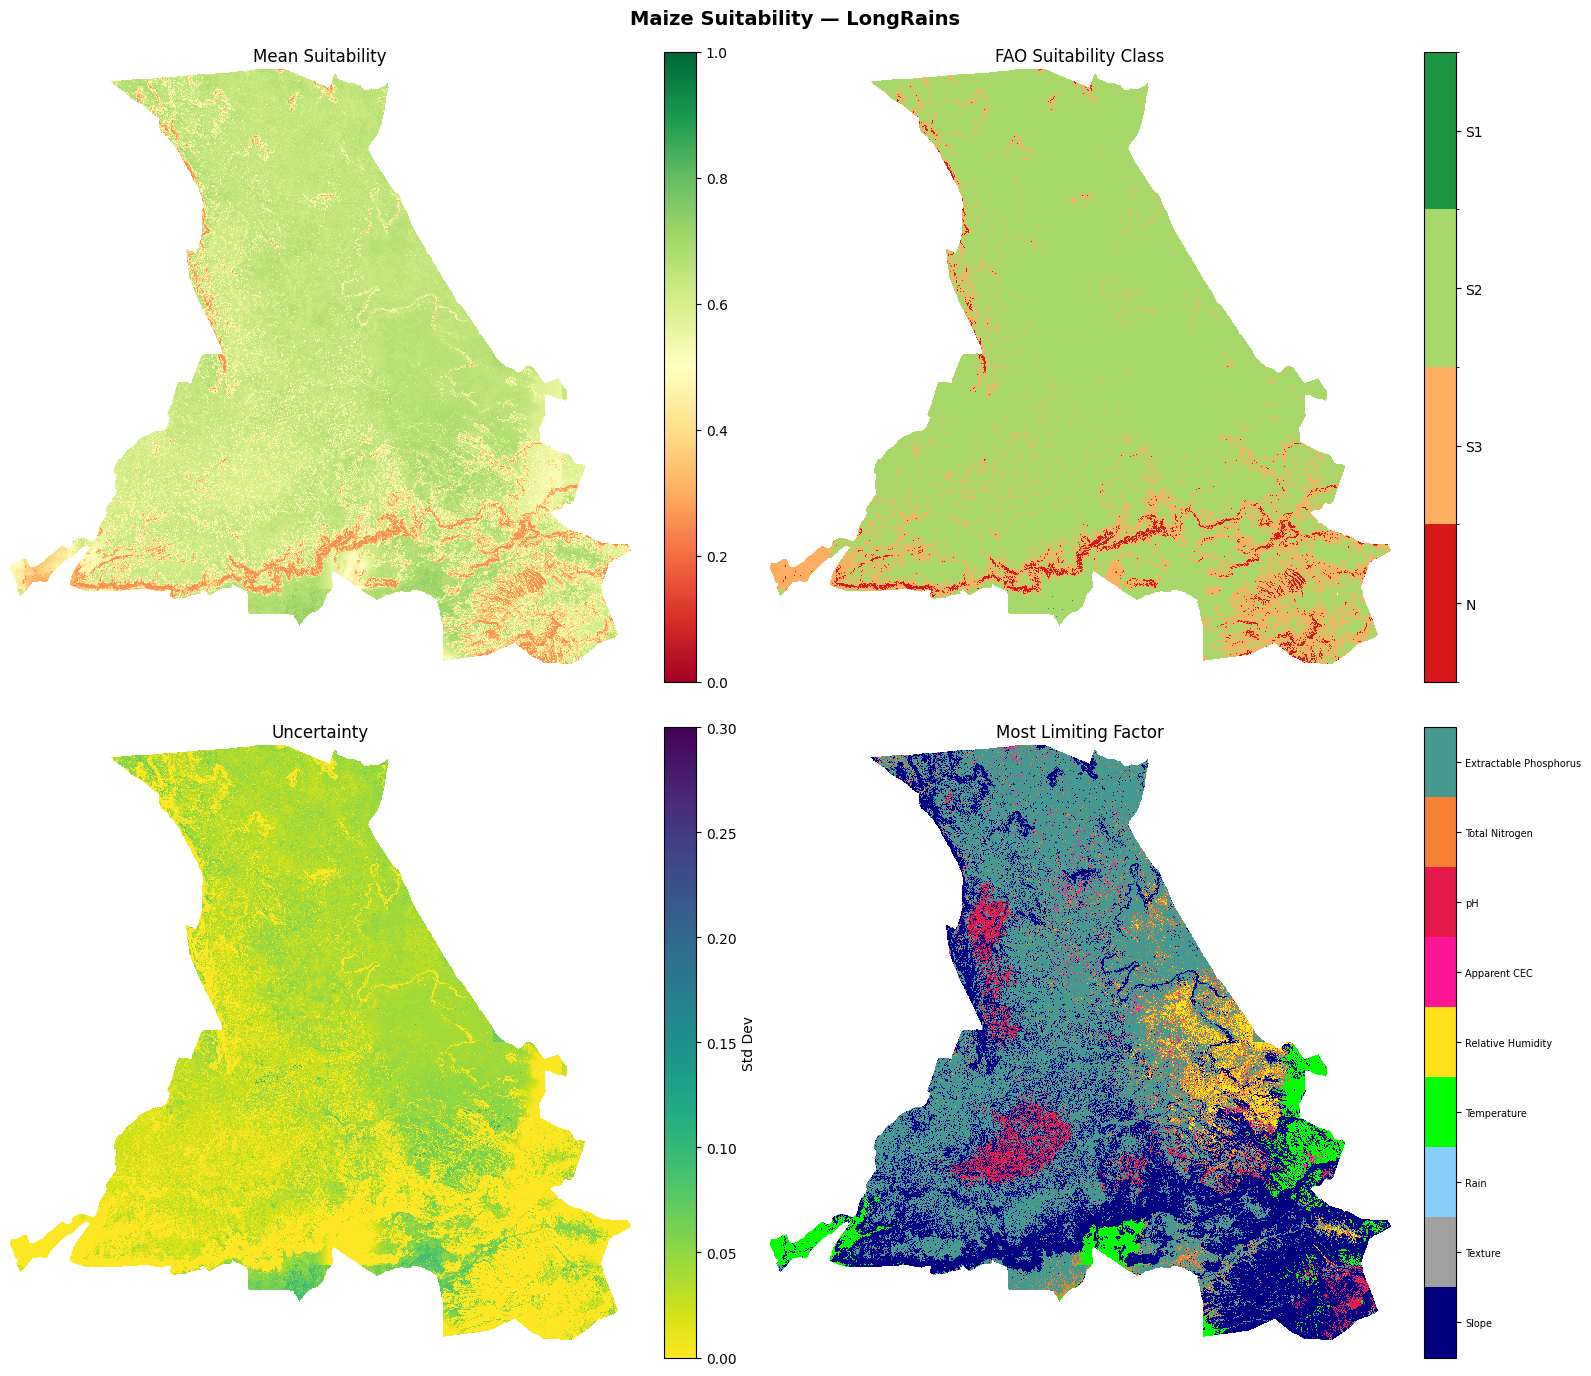

  Map saved: /content/drive/MyDrive/02_NandiSeedRecommender2/Outputs/Suitability_Map_LongRains.png

  Season: ShortRains
  Computing 5-band phase risk counts for ShortRains...
  Running tiled MC (N=100, 110 tiles)...
    Tile 1/110  [0:256, 0:256]
    Tile 21/110  [256:512, 2304:2560]
    Tile 41/110  [768:1024, 1792:2048]
    Tile 61/110  [1280:1536, 1280:1536]
    Tile 81/110  [1792:2048, 768:1024]
    Tile 101/110  [2304:2488, 256:512]

  Summary — ShortRains:
    Mean suitability : 0.537
    S1:      660 px  (0.0%)
    S2: 2,174,321 px  (68.5%)
    S3:  926,573 px  (29.2%)
    N:   74,802 px  (2.4%)

    Ranked Constraints & Climate Risks (ShortRains):
      [RISK ] prob_overall_fail   : 56.5816%
      [RISK ] prob_drought        : 53.8702%
      [LIMIT] rain                : 41.4908%
      [LIMIT] slope               : 28.9949%
      [LIMIT] phosphorus          : 14.5922%
      [RISK ] prob_flood          : 10.7550%
      [LIMIT] total_nitrogen      : 8.9360%
      [RISK ] prob_he

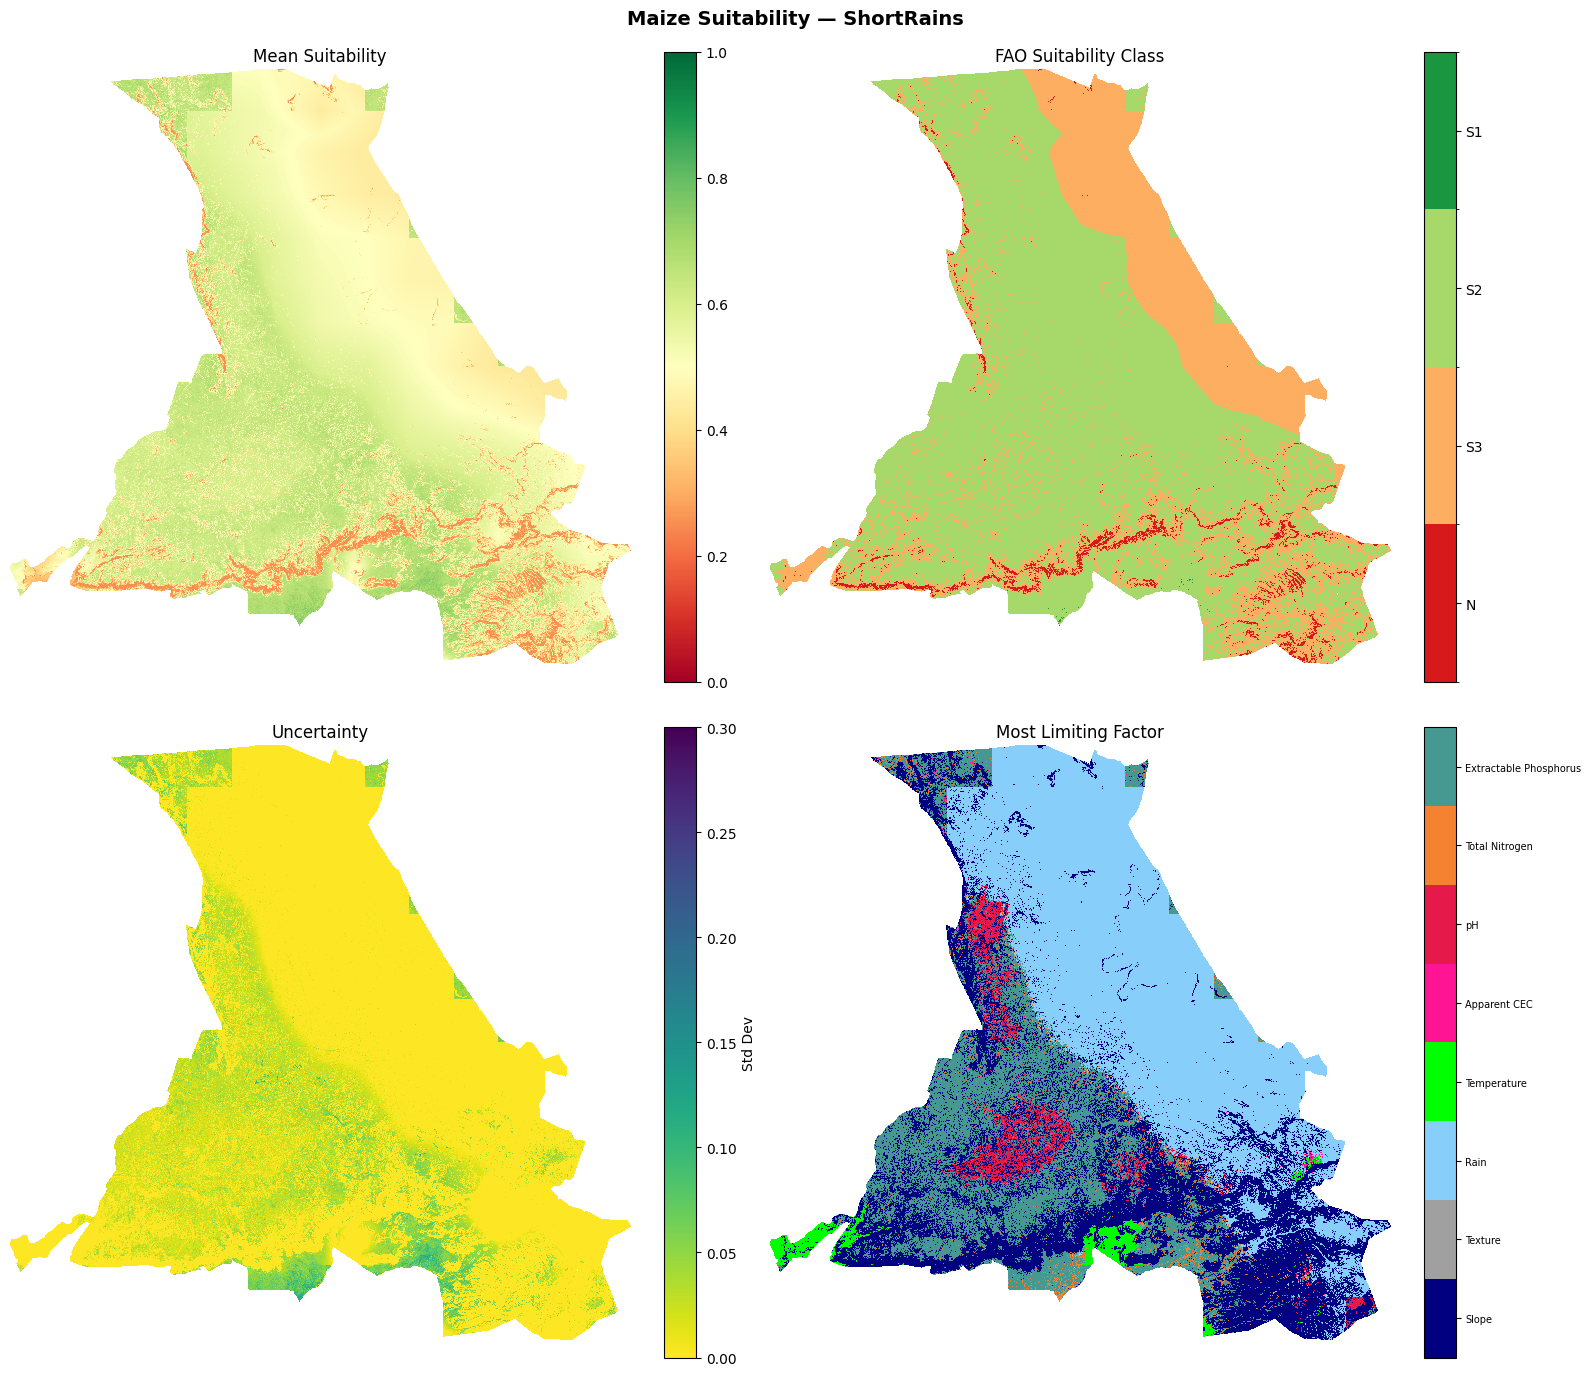

  Map saved: /content/drive/MyDrive/02_NandiSeedRecommender2/Outputs/Suitability_Map_ShortRains.png

Generating country-wide stats JSON

Done. Outputs saved to: /content/drive/MyDrive/02_NandiSeedRecommender2/Outputs


In [3]:
outputs = run_pipeline(n_mc=100, tile_size=256)

In [ ]:
def get_comprehensive_nandi_report(lat, lon, seed_df, season='LongRains'):
    import rasterio
    import os
    import numpy as np
    import pandas as pd
    import json
    from rasterio.transform import rowcol

    # Paths
    FINAL_DIR = os.path.join(BASE, 'Final_Outputs')
    FACTORS_DIR = os.path.join(FINAL_DIR, f'Factors_{season}')
    RAW_DIR = os.path.join(FINAL_DIR, f'Raw_Values_{season}')

    UNITS = {
        'ph': '', 'total_nitrogen': '%', 'phosphorus': 'mg/kg', 'potassium': 'cmol/kg',
        'calcium': 'cmol/kg', 'magnesium': 'cmol/kg', 'organic_carbon': '%',
        'ecec': 'cmol/kg', 'zinc': 'mg/kg', 'iron': 'mg/kg', 'clay_content': '%',
        'slope': '%', 'rain': 'mm', 'temp': '°C', 'rh': '%', 'bedrock_depth': 'cm',
        'elevation': 'm', 'stone_content': '%', 'cec_apparent': 'cmol/kg'
    }

    # 1. Load Baseline Context (Scores + Raw)
    json_path = os.path.join(FINAL_DIR, 'County_Averages.json')
    county_ref = {'scores': {}, 'raw': {}}
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            all_stats = json.load(f)
            county_ref = all_stats.get(season, {})

    # 2. Extract Overall Suitability
    suit_path = os.path.join(FINAL_DIR, f'Suit_Mean_{season}.tif')
    with rasterio.open(suit_path) as src:
        row, col = src.index(lon, lat)
        suit_mu = src.read(1)[row, col]
        if np.isnan(suit_mu): return "Coordinates outside mask."

    with rasterio.open(os.path.join(FINAL_DIR, f'Suit_Std_{season}.tif')) as src:
        suit_std = src.read(1)[row, col]

    # 3. Helper for Raw Values (including standalone Elevation)
    def get_raw_val(var):
        # Check season-specific raw folder first
        path = os.path.join(RAW_DIR, f'{var}_raw.tif')
        # Check root final folder second (for elevation)
        if not os.path.exists(path):
            path = os.path.join(FINAL_DIR, 'Nandi_Elevation_30m.tif') if var == 'elevation' else ""

        if os.path.exists(path):
            with rasterio.open(path) as s: return s.read(1)[row, col]
        return np.nan

    elev_val   = get_raw_val('elevation')
    precip_val = get_raw_val('rain')
    temp_val   = get_raw_val('temp')

    # 4. Stress Diagnosis & Seed Ranking
    stress_codes = []
    if temp_val < 16: stress_codes.append("cold")
    if temp_val > 30: stress_codes.append("heat")
    if precip_val < 450: stress_codes.append("dry")

    # Calls your inspiration logic function
    recommendations = rank_seed_varieties(seed_df, elevation=elev_val,
                                          precip=precip_val, stress_types=stress_codes)

    # 5. Fetch Factors (Separating Soil vs Physical)
    soil_vars = {'ph', 'total_nitrogen', 'phosphorus', 'potassium', 'calcium', 'magnesium',
                 'organic_carbon', 'ecec', 'cec_apparent', 'zinc', 'iron', 'clay_content'}

    soil_list, phys_list = [], []
    factor_files = [f for f in os.listdir(FACTORS_DIR) if f.endswith('_mean.tif')]

    for f_name in factor_files:
        var = f_name.replace('_mean.tif', '')
        with rasterio.open(os.path.join(FACTORS_DIR, f_name)) as m_f, \
             rasterio.open(os.path.join(FACTORS_DIR, f'{var}_std.tif')) as s_f:
            score = m_f.read(1)[row, col]
            unc = s_f.read(1)[row, col]

            entry = {
                'var': var, 'score': score, 'unc': unc, 'actual': get_raw_val(var),
                'avg_score': county_ref.get('scores', {}).get(var, 0),
                'avg_raw': county_ref.get('raw', {}).get(var, 0),
                'unit': UNITS.get(var, '')
            }
            if var in soil_vars: soil_list.append(entry)
            else: phys_list.append(entry)

    # Sort by Bottleneck (Lowest Score)
    soil_list.sort(key=lambda x: x['score'])
    phys_list.sort(key=lambda x: x['score'])

    # 6. Fetch Climate Risks
    risk_labels = ['Cold Risk', 'Heat Risk', 'Drought Risk', 'Flood Risk', 'Overall Failure']
    risk_keys = ['prob_cold', 'prob_heat', 'prob_drought', 'prob_flood', 'prob_overall_fail']
    risk_data = []
    with rasterio.open(os.path.join(FINAL_DIR, f'Risks_Mean_{season}.tif')) as m_f, \
         rasterio.open(os.path.join(FINAL_DIR, f'Risks_Std_{season}.tif')) as s_f:
        mu_r = m_f.read(window=((row, row+1), (col, col+1)))[:, 0, 0]
        st_r = s_f.read(window=((row, row+1), (col, col+1)))[:, 0, 0]
        for i, label in enumerate(risk_labels):
            risk_data.append({
                'label': label, 'mu': mu_r[i], 'std': st_r[i],
                'avg': county_ref.get('scores', {}).get(risk_keys[i], 0)
            })

    # --- PRINT FINAL FORMATTED REPORT ---
    print(f"\n{'='*125}")
    print(f" NANDI PRECISION AGRICULTURE: COMPREHENSIVE REPORT | {season}")
    print(f" GPS: {lat}, {lon} | Elevation: {elev_val:.0f}m | Overall Suitability: {suit_mu*100:.1f}% (±{suit_std:.3f})")
    print(f"{'='*125}")

    # Section A: TOP MANAGEMENT PRIORITIES
    print(f"\n{'MANAGEMENT PRIORITIES (Lowest Bars in the Bucket)':<50}")
    print("-" * 125)
    # Combine lists to find overall top 3 limiting factors
    all_f = sorted(soil_list + phys_list, key=lambda x: x['score'])
    for i in range(3):
        f = all_f[i]
        val_str = f"{f['actual']:.2f} {f['unit']}" if not np.isnan(f['actual']) else "N/A"
        print(f"  {i+1}. {f['var'].upper():<15} | Current: {val_str:<12} | Score: {f['score']:.3f} | Priority: HIGH")

    # Section B: SEED RECOMMENDATIONS
    print(f"\n{'SEED VARIETY RECOMMENDATIONS (Based on Local Stress)':<50}")
    print("-" * 125)
    display_cols = ['Variety', 'Potential yield (t/Ha)', 'Maturity (Days)', 'RequirementNotes']
    print(recommendations[display_cols].to_string(index=False))

    # Section C: DETAILED FEATURE ANALYSIS
    header = f"{'VARIABLE':<20} | {'MEASURED':<15} | {'COUNTY AVG':<15} | {'SCORE':<10} | {'UNCERTAINTY'}"

    print(f"\n{header}")
    print("-" * 125)
    print("CLIMATE RISKS (10-Year Probabilities)")
    for r in risk_data:
        print(f"{r['label']:<20} | {r['mu']*100:>13.1f}% | {r['avg']*100:>13.1f}% | {r['mu']:>10.3f} | ±{r['std']:.3f}")

    print("\nSOIL NUTRIENTS & PROPERTIES")
    for s in soil_list:
        act = f"{s['actual']:>8.2f} {s['unit']}" if not np.isnan(s['actual']) else "N/A"
        avg = f"{s['avg_raw']:>8.2f} {s['unit']}" if s['avg_raw'] > 0 else "N/A"
        print(f"{s['var']:<20} | {act:<15} | {avg:<15} | {s['score']:>10.3f} | ±{s['unc']:.3f}")

    print("\nPHYSICAL & TOPOGRAPHY")
    for p in phys_list:
        act = f"{p['actual']:>8.2f} {p['unit']}" if not np.isnan(p['actual']) else "N/A"
        avg = f"{p['avg_raw']:>8.2f} {p['unit']}" if p['avg_raw'] > 0 else "N/A"
        print(f"{p['var']:<20} | {act:<15} | {avg:<15} | {p['score']:>10.3f} | ±{p['unc']:.3f}")

    print(f"{'='*125}\n")


 COMPREHENSIVE OFFLINE REPORT | LongRains
 Location: 0.15, 35.1 | Suitability: 0.59 (±0.000)
CLIMATE RISK (Extreme Weather) | Probability  | Uncertainty  | County Avg
------------------------------------------------------------------------------------------
Cold Risk                 |        4.8% |        0.0% |      5.9%
Heat Risk                 |        4.6% |        0.0% |      5.9%
Drought Risk              |        1.0% |        0.0% |     16.1%
Flood Risk                |        6.8% |        0.0% |     14.3%
Overall Failure           |       12.3% |        0.0% |     23.6%

SOIL NUTRIENTS & PROPERTIES | Score (0-1)  | Uncertainty  | County Avg
------------------------------------------------------------------------------------------
phosphorus                |        0.614 |        0.000 |      0.683
total_nitrogen            |        0.637 |        0.000 |      0.782
ph                        |        0.738 |        0.000 |      0.826
cec_apparent              |        0.907 

Can we say if it will be an el nino / la nina year - as a tick box?

In [ ]:
def get_report_from_disk(lat, lon, season='LongRains'):
    """
    Extracts all data strictly from the GeoTIFF files saved in DIR_OUT.
    No reliance on memory-stored dictionaries.
    """
    import rasterio
    import os
    import numpy as np

    # 1. Define Paths to your saved outputs
    path_suit_mu  = os.path.join(DIR_OUT, f'Suitability_Mean_{season}.tif')
    path_suit_std = os.path.join(DIR_OUT, f'Suitability_Std_{season}.tif')
    path_suit_cls = os.path.join(DIR_OUT, f'Suitability_Class_{season}.tif')
    path_risk_mu  = os.path.join(DIR_OUT, f'Risk_Means_{season}.tif')
    path_risk_std = os.path.join(DIR_OUT, f'Risk_Uncertainty_{season}.tif')

    # For physical factors, we need to know where the model stores individual factor TIFs
    # In your Section 9, we saved 'Advisory' and potentially other per-variable TIFs.

    if not os.path.exists(path_suit_mu):
        return f"Error: Could not find output files in {DIR_OUT}. Did the pipeline finish?"

    report = {}

    with rasterio.open(path_suit_mu) as src:
        # Convert GPS to Pixel Coordinates
        row, col = src.index(lon, lat)

        # Boundary Check
        if not (0 <= row < src.height and 0 <= col < src.width):
            return "Error: Coordinates are outside the mapped area of Nandi."

        # 2. Suitability Data
        s_mu = src.read(1)[row, col]
        if np.isnan(s_mu):
            return "Location has no data (Outside Nandi mask)."

        with rasterio.open(path_suit_std) as s_std_f:
            s_std = s_std_f.read(1)[row, col]
        with rasterio.open(path_suit_cls) as s_cls_f:
            s_cls = s_cls_f.read(1)[row, col]

    # 3. Climate Risk Data (5-Band Files)
    risk_labels = ['Cold', 'Heat', 'Drought', 'Flood', 'Overall Failure']
    risks = {}
    with rasterio.open(path_risk_mu) as r_mu_f, rasterio.open(path_risk_std) as r_std_f:
        # Read all 5 bands at the specific pixel
        mu_values = r_mu_f.read(window=((row, row+1), (col, col+1)))[:, 0, 0]
        std_values = r_std_f.read(window=((row, row+1), (col, col+1)))[:, 0, 0]

        for i, label in enumerate(risk_labels):
            risks[label] = {"Mean": mu_values[i], "Std": std_values[i]}

    # 4. Display the Report
    print(f"\n{'='*55}")
    print(f" FINAL LOCATION REPORT (DISK-LOADED): {season}")
    print(f"{'='*55}")
    print(f"Coordinates: {lat}, {lon}")

    class_names = {1: "S1 (Highly Suitable)", 2: "S2", 3: "S3", 4: "N (Not Suitable)"}
    print(f"Suitability: {s_mu:.2f} (±{s_std:.3f}) -> {class_names.get(int(s_cls), 'N/A')}")

    print("-" * 30)
    print("CLIMATE RISKS (ENSO-Conditioned):")
    for label, val in risks.items():
        print(f"  - {label:<17}: {val['Mean']*100:>5.1f}% (±{val['Std']*100:.2f}%)")

    print("-" * 30)
    print("Note: To see the top 5 physical limiting factors from disk,")
    print("      ensure per-variable TIFs are saved in Section 9.")

    return report

# Usage:
get_report_from_disk(0.15, 35.10)


 FINAL LOCATION REPORT (DISK-LOADED): LongRains
Coordinates: 0.15, 35.1
Suitability: 0.59 (±0.000) -> S2
------------------------------
CLIMATE RISKS (ENSO-Conditioned):
  - Cold             :   4.8% (±0.00%)
  - Heat             :   4.6% (±0.00%)
  - Drought          :   1.0% (±0.00%)
  - Flood            :   6.8% (±0.00%)
  - Overall Failure  :  12.3% (±0.00%)
------------------------------
Note: To see the top 5 physical limiting factors from disk,
      ensure per-variable TIFs are saved in Section 9.


{}

In [ ]:
def get_report_from_disk(lat, lon, season='LongRains'):
    """
    Extracts all data strictly from the GeoTIFF files saved in DIR_OUT.
    No reliance on memory-stored dictionaries.
    """
    import rasterio
    import os
    import numpy as np

    # 1. Define Paths to your saved outputs
    path_suit_mu  = os.path.join(DIR_OUT, f'Suitability_Mean_{season}.tif')
    path_suit_std = os.path.join(DIR_OUT, f'Suitability_Std_{season}.tif')
    path_suit_cls = os.path.join(DIR_OUT, f'Suitability_Class_{season}.tif')
    path_risk_mu  = os.path.join(DIR_OUT, f'Risk_Means_{season}.tif')
    path_risk_std = os.path.join(DIR_OUT, f'Risk_Uncertainty_{season}.tif')

    # For physical factors, we need to know where the model stores individual factor TIFs
    # In your Section 9, we saved 'Advisory' and potentially other per-variable TIFs.

    if not os.path.exists(path_suit_mu):
        return f"Error: Could not find output files in {DIR_OUT}. Did the pipeline finish?"

    report = {}

    with rasterio.open(path_suit_mu) as src:
        # Convert GPS to Pixel Coordinates
        row, col = src.index(lon, lat)

        # Boundary Check
        if not (0 <= row < src.height and 0 <= col < src.width):
            return "Error: Coordinates are outside the mapped area of Nandi."

        # 2. Suitability Data
        s_mu = src.read(1)[row, col]
        if np.isnan(s_mu):
            return "Location has no data (Outside Nandi mask)."

        with rasterio.open(path_suit_std) as s_std_f:
            s_std = s_std_f.read(1)[row, col]
        with rasterio.open(path_suit_cls) as s_cls_f:
            s_cls = s_cls_f.read(1)[row, col]

    # 3. Climate Risk Data (5-Band Files)
    risk_labels = ['Cold', 'Heat', 'Drought', 'Flood', 'Overall Failure']
    risks = {}
    with rasterio.open(path_risk_mu) as r_mu_f, rasterio.open(path_risk_std) as r_std_f:
        # Read all 5 bands at the specific pixel
        mu_values = r_mu_f.read(window=((row, row+1), (col, col+1)))[:, 0, 0]
        std_values = r_std_f.read(window=((row, row+1), (col, col+1)))[:, 0, 0]

        for i, label in enumerate(risk_labels):
            risks[label] = {"Mean": mu_values[i], "Std": std_values[i]}

    # 4. Display the Report
    print(f"\n{'='*55}")
    print(f" FINAL LOCATION REPORT (DISK-LOADED): {season}")
    print(f"{'='*55}")
    print(f"Coordinates: {lat}, {lon}")

    class_names = {1: "S1 (Highly Suitable)", 2: "S2", 3: "S3", 4: "N (Not Suitable)"}
    print(f"Suitability: {s_mu:.2f} (±{s_std:.3f}) -> {class_names.get(int(s_cls), 'N/A')}")

    print("-" * 30)
    print("CLIMATE RISKS (ENSO-Conditioned):")
    for label, val in risks.items():
        print(f"  - {label:<17}: {val['Mean']*100:>5.1f}% (±{val['Std']*100:.2f}%)")

    print("-" * 30)
    print("Note: To see the top 5 physical limiting factors from disk,")
    print("      ensure per-variable TIFs are saved in Section 9.")

    return report

# Usage:
# get_report_from_disk(0.15, 35.10)

NameError: name 'all_vars' is not defined

In [ ]:
# Replace with your coordinates
test_lon, test_lat = 35.32, -0.009

generate_maize_report(test_lon, test_lat, outputs, soil, climate, elevation)

Enter Season (Long/Short): Long

 MAIZE SUITABILITY REPORT: LongRains
 Location: -0.0090, 35.3200

CURRENT CONDITIONS        |      VALUE
--------------------------------------
Elevation (m)             |     1733.0
Temperature (°C)          |        nan
Precipitation (mm)        |      763.5
Soil pH                   |       5.60
Organic Carbon (%)        |       1.91
Slope (%)                 |       38.6
--------------------------------------

OVERALL SUITABILITY |██████████--------------------| 33.5%

--------------- TOP 5 ABSOLUTE CONSTRAINTS ---------------
These are the primary reasons for your current suitability score:
 1. Slope                | Score: 0.3354
 2. Rh                   | Score: 0.7705
 3. Rain                 | Score: 0.8621
 4. Total Nitrogen       | Score: 0.9297
 5. Organic Carbon       | Score: 0.9580

--------------- TOP 5 ACTIONABLE SOIL STEPS ---------------
Improve these to increase your yield potential:
 1. Phosphorus           | Score: 0.9069 (Monitor)

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio
from scipy import stats

# ============================================================
# PATH CONFIGURATION (Matched to your Nandi Model)
# ============================================================
BASE         = '/content/drive/MyDrive/02_NandiSeedRecommender2'
DIR_SOIL     = os.path.join(BASE, 'Soil_Data')
DIR_SOIL_UNC = os.path.join(BASE, 'Soil_Data_Uncertainty')

def decode_isda(arr, var_name):
    """
    Applies the specific iSDA back-transformation AND scaling
    matched exactly to your Nandi Model logic.
    """
    # 1. pH Handling (Linear + 0.1 Scale)
    if "pH" in var_name:
        return arr * 0.1

    # 2. Nitrogen Handling (Log 100 + 0.1 Scale)
    if "Total_Nitrogen" in var_name:
        return np.expm1(arr / 100.0) * 0.1

    # 3. Organic Carbon (Log 10 + 0.1 Scale)
    if "Organic_Carbon" in var_name:
        return np.expm1(arr / 10.0) * 0.1

    # 4. Atomic Weight Scaled Nutrients (Log 10 + Weight Scale)
    if "Calcium" in var_name:
        return np.expm1(arr / 10.0) * (1/200.39)
    if "Magnesium" in var_name:
        return np.expm1(arr / 10.0) * (1/121.53)
    if "Potassium" in var_name:
        return np.expm1(arr / 10.0) * (1/390.98)

    # 5. Bedrock (Linear, No Scale)
    if "Bedrock" in var_name:
        return arr

    # 6. Default (Log 10, No Scale - e.g. Phosphorus, Zinc, Iron)
    return np.expm1(arr / 10.0)

def run_distribution_check():
    results = []

    # We focus on the Mean (mu) files in the main Soil_Data folder
    tifs = [f for f in os.listdir(DIR_SOIL) if f.endswith('.tif')]

    print(f"Analyzing {len(tifs)} variables for log-normality...")

    for tif in tifs:
        path = os.path.join(DIR_SOIL, tif)
        var_label = tif.replace(".tif", "")

        with rasterio.open(path) as src:
            # Read a sample to stay within Shapiro-Wilk limits and RAM
            # We take a window from the center or a random sample
            data = src.read(1).flatten()
            nodata = src.nodata

            # Filter NoData and non-positive values
            clean_data = data[np.isfinite(data)]
            if nodata is not None:
                clean_data = clean_data[clean_data != nodata]

            # iSDA raw values are often log-encoded; we decode to see
            # if the NATURAL values follow a log-normal distribution
            decoded_data = decode_isda(clean_data, var_label)
            decoded_data = decoded_data[decoded_data > 0]

            if len(decoded_data) < 10:
                continue

            # Limit sample to 5000 for Shapiro-Wilk test consistency
            sample_size = min(len(decoded_data), 5000)
            sample = np.random.choice(decoded_data, sample_size, replace=False)

            # Test 1: Log-transform the decoded data
            log_sample = np.log(sample)

            # Test 2: Shapiro-Wilk for normality on the LOGGED data
            # H0: The data is log-normal
            _, p_val = stats.shapiro(log_sample)

            # Metrics for decision making
            raw_skew = stats.skew(sample)
            cv = np.std(sample) / np.mean(sample)

            # Decision: If p > 0.05, the log-transform successfully normalized the data
            is_log_normal = p_val > 0.05

            results.append({
                'Variable': var_label,
                'Raw_Skew': round(raw_skew, 3),
                'CV': round(cv, 3),
                'P_Value': round(p_val, 5),
                'Log_Normal_Suggested': "YES" if is_log_normal else "NO"
            })

    df = pd.DataFrame(results)

    # Sort by Log-Normal likelihood
    df = df.sort_values(by='P_Value', ascending=False)

    print("\n--- Distribution Analysis Results ---")
    print(df.to_string(index=False))

    # Suggested update for your LOG_NORMAL_VARS set
    suggested = df[df['Log_Normal_Suggested'] == "YES"]['Variable'].tolist()
    print("\nRecommended for LOG_NORMAL_VARS set:")
    print(suggested)

    return df

if __name__ == "__main__":
    analysis_results = run_distribution_check()

Analyzing 35 variables for log-normality...

--- Distribution Analysis Results ---
                             Variable  Raw_Skew    CV  P_Value Log_Normal_Suggested
                iSDA_Magnesium_0-20cm     1.246 0.244      0.0                   NO
               iSDA_Phosphorus_0-20cm     0.590 0.203      0.0                   NO
           iSDA_Total_Nitrogen_0-20cm     0.895 0.233      0.0                   NO
           iSDA_Organic_Carbon_0-20cm     0.754 0.216      0.0                   NO
                iSDA_Potassium_0-20cm     0.695 0.181      0.0                   NO
                     iSDA_Zinc_0-20cm     0.390 0.126      0.0                   NO
                   iSDA_Sulfur_0-20cm     0.296 0.158      0.0                   NO
                  iSDA_Calcium_0-20cm     1.072 0.260      0.0                   NO
                       iSDA_pH_0-20cm     0.246 0.033      0.0                   NO
            iSDA_stone_content_0-20cm     1.325 0.444      0.0               